In [1]:
# You may need to run this once
#%pip install scikit-learn

# - Loading of all the functions needed

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import random
import sys
sys.path.append("../src/")  
from event_io import load_events_csv, Event, Particle
from features import dphi, dR, build_features
from model import make_mlp
from cuts import pass_cuts
from train import train_model


# - MLP training with a convergence criterion (eg. early stopping)
Split, standardize and plot

- The data in the csv file pythia is used for training the neural network. The contents are shuffled so that the learning process stays unbiased and the model learns from a diverse dataset.
- The network would take an input of 10 features - and determine whether the jet came from a vector boson(output = 1) or not (output = 0)
- To form the required datasets, the main dataset is divided into 2 subdatasets, training and validation.
- The data from the training dataset will be used to train the model, while the validation set is used to fine tune the performance of the model. It prevents the model from overfitting.
- The input features are - { $\ p_{t}^j$, $\eta^j$, $\phi^j$, $\ p_{t}^l$, $\eta^l$, $\phi^l$, $\Delta \phi(j,l)$, $\Delta R(j,l)$, $\ p_{t}^j / \ p_{t}^l$, $(\ p_{t}^j - \ p_{t}^l)/(\ p_{t}^j + \ p_{t}^l)$ }
- All the feaures are standardized to ensure that all input features are on comparable scales to train the model efficiently.

Train: (3949, 10) Val: (2633, 10)
x_data shape: (6582, 10)
y_data shape: (6582,)
signal fraction: 0.4762989972652689


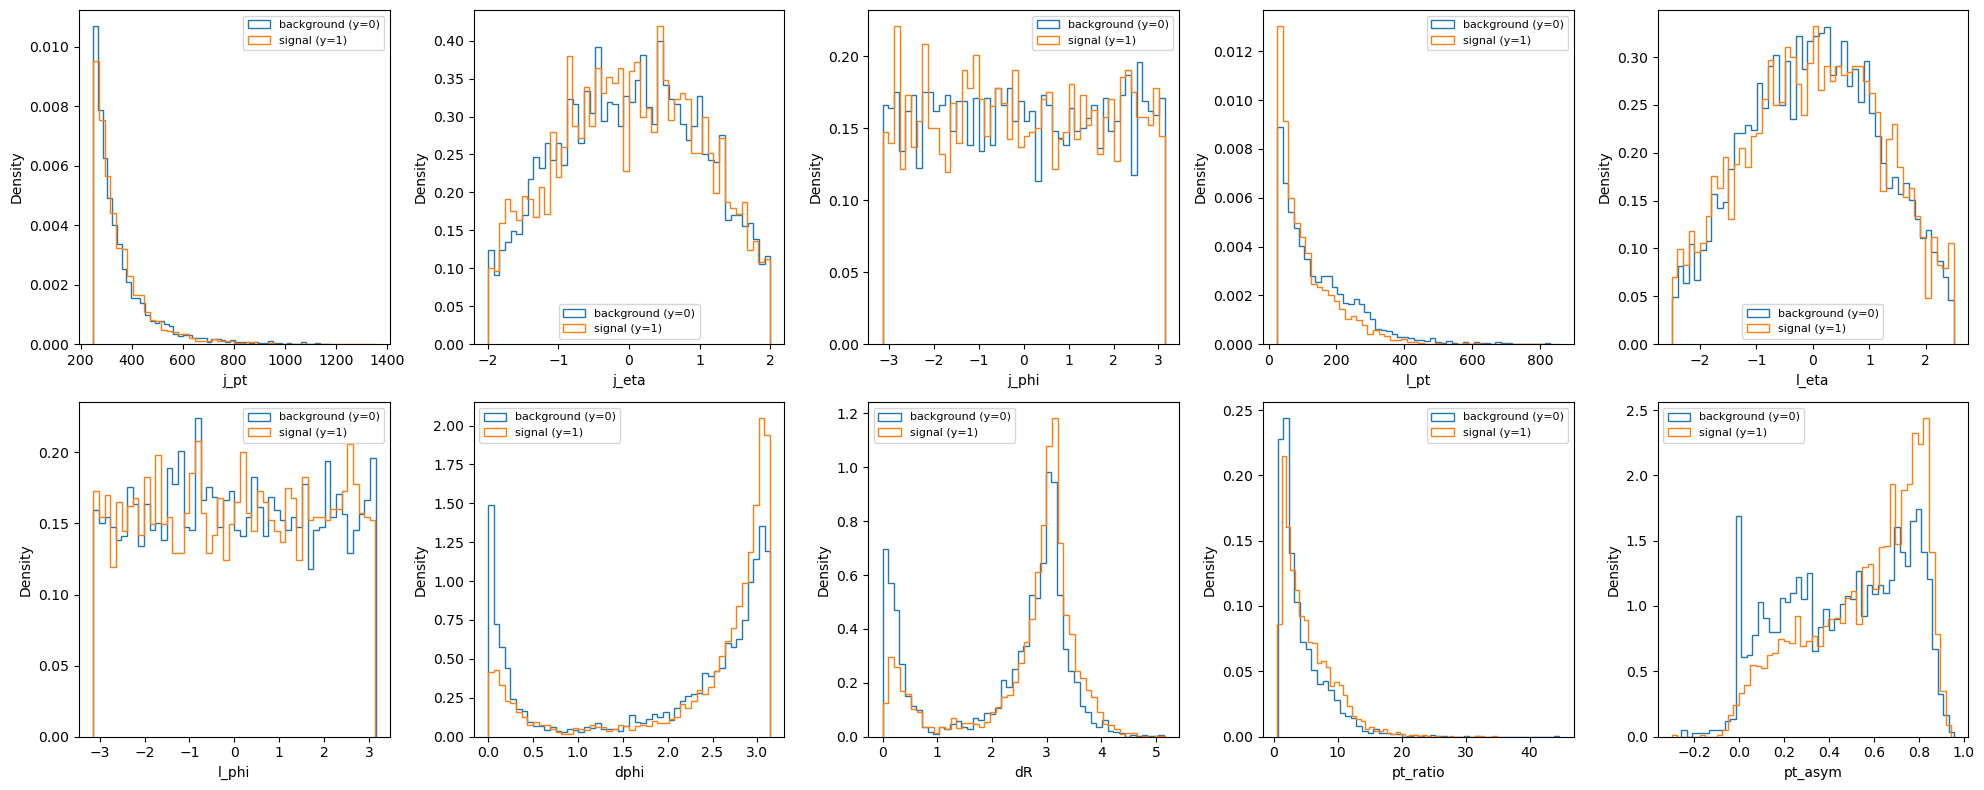

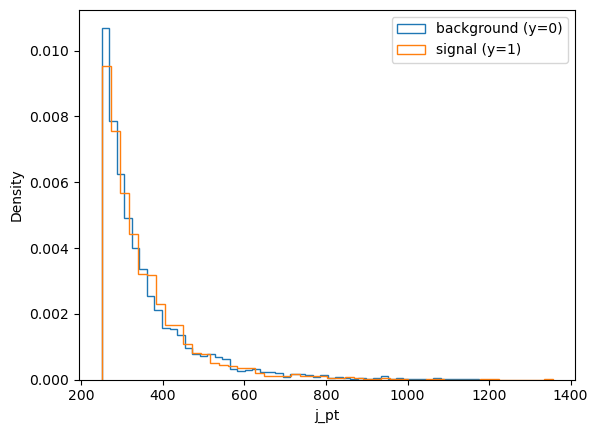

In [3]:
# -----------------------------
# Build the dataset from MC
# -----------------------------
MC_FILE = "../data/pythia.csv"
mc_events = load_events_csv(MC_FILE)

X_list, y_list, eid_list = [], [], []

for e in mc_events:
    x = build_features(e)
    j = e.leading_jet()
    if x is None or j is None:
        continue
    X_list.append(x)
    y_list.append(1 if j.truth else 0)
    eid_list.append(e.event_id)

x_data = np.stack(X_list)
y_data = np.array(y_list, dtype=int)
eid_data = np.array(eid_list, dtype=int)

# Split 60/40 by event_id
rng = np.random.default_rng(42)
unique_eids = np.unique(eid_data) #make sure each event has one entry

rng.shuffle(unique_eids)

split = int(0.6 * len(unique_eids))
train_eids = set(unique_eids[:split])
val_eids   = set(unique_eids[split:])

train_mask = np.array([eid in train_eids for eid in eid_data])
val_mask   = ~train_mask

X_train = x_data[train_mask]
y_train = y_data[train_mask]

X_val   = x_data[val_mask]
y_val   = y_data[val_mask]

print("Train:", X_train.shape, "Val:", X_val.shape)

# Standardize values
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
sigma[sigma == 0] = 1.0 #avoid division by zero

X_train_std = (X_train - mu) / sigma
X_val_std   = (X_val   - mu) / sigma

print("x_data shape:", x_data.shape)
print("y_data shape:", y_data.shape)
print("signal fraction:", y_data.mean())
feature_names = ["j_pt","j_eta","j_phi","l_pt","l_eta","l_phi","dphi","dR","pt_ratio","pt_asym"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()  # makes indexing easier

for k in range(10):
    ax = axes[k]

    ax.hist(
        x_data[y_data == 0, k],
        bins=50,
        histtype="step",
        density=True,
        label="background (y=0)"
    )

    ax.hist(
        x_data[y_data == 1, k],
        bins=50,
        histtype="step",
        density=True,
        label="signal (y=1)"
    )

    ax.set_xlabel(feature_names[k])
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/background_signal_all_features.png",
            dpi=300,
            bbox_inches="tight")
plt.show()   

k = 0  # pick a feature index to inspect, start with 0 = j_pt from feature_names
plt.hist(x_data[y_data==0, k], bins=50, histtype="step", density=True, label="background (y=0)")
plt.hist(x_data[y_data==1, k], bins=50, histtype="step", density=True, label="signal (y=1)")
plt.xlabel(feature_names[k])
plt.ylabel("Density")
plt.legend()
plt.savefig("../outputs/backrgound&signal.png", dpi=300, bbox_inches="tight")
plt.show()


In this cell we started building an ML dataset from the MC datafile. We made 3 different lists from the data, X, Y and EID. In X we stored the 10D feature vector, in Y the labels (0 for background, 1 for signal), and in EID the event IDs. We then split the MC by event ID. Here, after shuffling event IDs randomly, we used a two-way split (60/40 sets for training and validation). We then standardized our features by making sure that they have mean 0 and standard deviation 1 (on the training set).

This plot shows the distribution of all the quantites in { $\ p_{t}^j$, $\eta^j$, $\phi^j$, $\ p_{t}^l$, $\eta^l$, $\phi^l$, $\Delta \phi(j,l)$, $\Delta R(j,l)$, $\ p_{t}^j / \ p_{t}^l$, $(\ p_{t}^j - \ p_{t}^l)/(\ p_{t}^j + \ p_{t}^l)$ }, both for the background (blue) and for the signal (orange) events. Both distributions look very similar in general with exceptions for { $\Delta \phi(j,l)$, $\Delta R(j,l)$, $(\ p_{t}^j - \ p_{t}^l)/(\ p_{t}^j + \ p_{t}^l)$ } which I have a very distinct peak for the background. This means that most features alone are not a good discriminator between background and signal events. 

This information can also show us neural networks should rely on correlations between variables (rather than instead using cut-based selections). For example, the shape of the distribution tells us that there are many jets at lower pT, and fewer at higher pT, with an exponential-like decrease.

In [4]:
# --- tensors ---
X_train_t = torch.tensor(X_train_std, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val_t   = torch.tensor(X_val_std, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# ----- 4-layer sigmoid network (input, 2 hidden, output) -----
in_dim  = 10 # Number of input dimensions
h1, h2  = 32, 16  # Two hidden layers with h1 and h2 neurons
dropout=0.1

model = make_mlp(in_dim, h1, h2, dropout)

# Inspect the network
print(model)
print("Number of trainable parameters:", sum(p.numel()
      for p in model.parameters() if p.requires_grad))

# Define Loss Function and Optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

Sequential(
  (0): Linear(in_features=10, out_features=32, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.1, inplace=False)
  (3): Linear(in_features=32, out_features=16, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.1, inplace=False)
  (6): Linear(in_features=16, out_features=1, bias=True)
)
Number of trainable parameters: 897


In this cell we start the neural network training itself. A neural network is created with 2 hidden layers of 32 and 16 features, the activation function is the Rectified Linear Unit(ReLU). This choice of activation function enables faster training and counters the vanishing gradient problem, wherein the gradients used for updating the weights shrink during backpropagation and compromise the learning process.

To do this, we convert numpy arrays to pytorch tensors. After that we define the network architecture (10 $\rightarrow $ 32 $\rightarrow $ 16 $\rightarrow $ 1), and apply dropout (at 10% rate). Dropout is a technique which randomly sets to zero a fraction (here 10%) of neurons in a layer, so that the next layer can't rely on it. Dropout can help to prevent the phenomenon of overfitting, where the network relies too much on the training data. At the of the cell we also defined the loss function and the optimizer.

In [5]:
# --- training settings ---
max_epochs = 400
batch_size = 256
patience = 50          # stop if val loss doesn't improve for x epochs
min_delta = 1e-6
train_losses = []
val_losses = []

model, train_losses, val_losses = train_model(
    model,
    X_train_t,
    y_train_t,
    X_val_t,
    y_val_t,
    optimizer,
    loss_fn,
    max_epochs,
    batch_size,
    patience,
    min_delta
)

Epoch   1 | train loss 0.6997 | val loss 0.6900 | best 0.6900 | no improve 0/50
Epoch   5 | train loss 0.6822 | val loss 0.6797 | best 0.6797 | no improve 0/50
Epoch  10 | train loss 0.6683 | val loss 0.6686 | best 0.6686 | no improve 0/50
Epoch  15 | train loss 0.6588 | val loss 0.6595 | best 0.6595 | no improve 0/50
Epoch  20 | train loss 0.6500 | val loss 0.6540 | best 0.6540 | no improve 0/50
Epoch  25 | train loss 0.6452 | val loss 0.6499 | best 0.6499 | no improve 0/50
Epoch  30 | train loss 0.6430 | val loss 0.6468 | best 0.6468 | no improve 0/50
Epoch  35 | train loss 0.6361 | val loss 0.6437 | best 0.6437 | no improve 0/50
Epoch  40 | train loss 0.6353 | val loss 0.6413 | best 0.6413 | no improve 0/50
Epoch  45 | train loss 0.6324 | val loss 0.6398 | best 0.6398 | no improve 0/50
Epoch  50 | train loss 0.6296 | val loss 0.6383 | best 0.6383 | no improve 0/50
Epoch  55 | train loss 0.6256 | val loss 0.6371 | best 0.6371 | no improve 0/50
Epoch  60 | train loss 0.6286 | val loss

The learning process takes place for a maximum of 400( max epochs) times through the training dataset. To increase efficiency, the training samples are divided into groups of 256 samples for processing. The 'Early Stopping' parameter is implemented via the 'patience' variable; If the validation loss doesn't get better after the required number of epochs, the learning process stops to prevent overfitting.
The 'min_delta' variable specifies the minimum change in the validation loss to term as an improvement.

We then initialized training loss and validation loss tracking. After that we called the train_model() function, which will loop over functions, split the data into batches, compute losses, update weights, and at the end it will apply early stopping. In the output we can see that both the training and validation losses are becoming smaller by each epoch, until the early stoppin happens. 


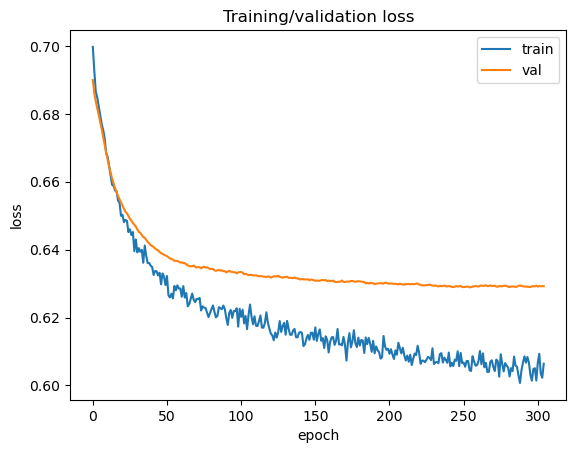

In [6]:
plt.figure()
plt.plot(train_losses, label="train")
plt.plot(val_losses, label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training/validation loss")
plt.legend()
plt.savefig("../outputs/Training&validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

The graph shows that with successive epochs, the losses on both datasets decreases. The validation curve eventually flattens typically at around 0.64 with few improvements, while training loss keeps decreasing. Early stopping prevents the model from continuing training in a regime where validation performance no longer improves, thereby limiting overfitting.

# - Code producing the ROC and purity curves.

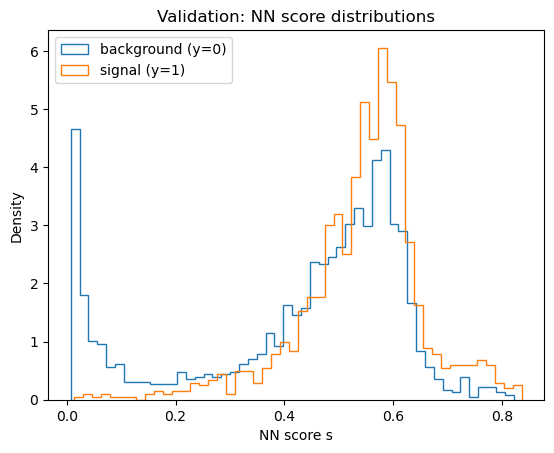

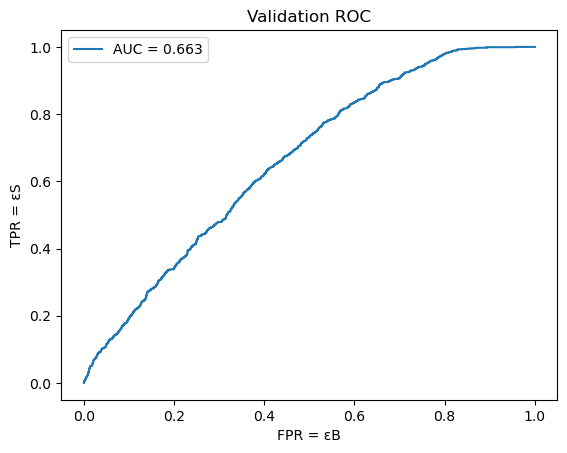

Validation AUC = 0.6631


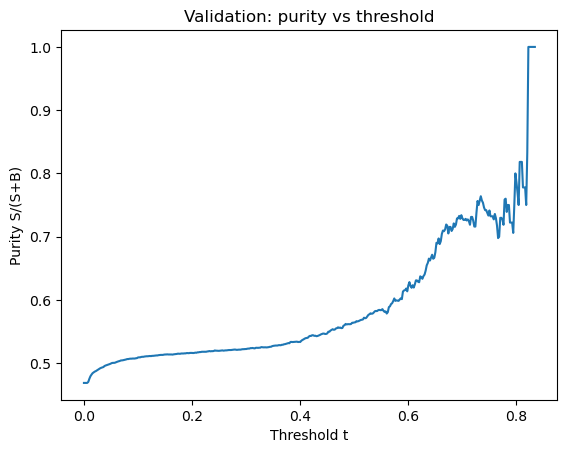

Chosen working point t* = 0.596
At t*: purity = 0.618, eps_S = 0.301, eps_B = 0.164


In [7]:
# --- 1) Get validation scores ---
model.eval()

with torch.no_grad(): #making predictions
    val_logits = model(X_val_t).squeeze(1).cpu().numpy()   # shape (N,)
val_scores = 1.0 / (1.0 + np.exp(-val_logits))             # sigmoid -> (0,1)

y_val_np = np.array(y_val).astype(int)

# --- 2) Plot score histograms ---
plt.figure()
plt.hist(val_scores[y_val_np == 0], bins=50, histtype="step", density=True, label="background (y=0)")
plt.hist(val_scores[y_val_np == 1], bins=50, histtype="step", density=True, label="signal (y=1)")
plt.xlabel("NN score s")
plt.ylabel("Density")
plt.title("Validation: NN score distributions")
plt.legend()
plt.savefig("../outputs/Validation_NN.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 3) ROC + AUC ---
fpr, tpr, roc_thresholds = roc_curve(y_val_np, val_scores) # Background and signal efficiency
auc = roc_auc_score(y_val_np, val_scores)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.xlabel("FPR = εB")
plt.ylabel("TPR = εS")
plt.title("Validation ROC")
plt.savefig("../outputs/Validation_ROC.png", dpi=300, bbox_inches="tight")
plt.legend()
plt.show()

print(f"Validation AUC = {auc:.4f}")

# --- 4) Purity vs threshold + choose working point ---
# Define a grid of thresholds (more fine than roc_thresholds, easier for purity curve)
thresholds = np.linspace(0.0, 1.0, 501)

S0 = np.sum(y_val_np == 1)
B0 = np.sum(y_val_np == 0)

purities = []
eps_S_list = []
eps_B_list = []

for t in thresholds:
    sel = val_scores >= t
    S = np.sum(sel & (y_val_np == 1))
    B = np.sum(sel & (y_val_np == 0))

    purity = S / (S + B) if (S + B) > 0 else np.nan
    eps_S  = S / S0 if S0 > 0 else np.nan
    eps_B  = B / B0 if B0 > 0 else np.nan

    purities.append(purity)
    eps_S_list.append(eps_S)
    eps_B_list.append(eps_B)

purities = np.array(purities)
eps_S_list = np.array(eps_S_list)
eps_B_list = np.array(eps_B_list)

plt.figure()
plt.plot(thresholds, purities)
plt.xlabel("Threshold t")
plt.ylabel("Purity S/(S+B)")
plt.title("Validation: purity vs threshold")
plt.savefig("../outputs/Validation_purity&threshold.png", dpi=300, bbox_inches="tight")
plt.show()

# Choose t* maximizing purity subject to eps_S >= 0.30
mask = eps_S_list >= 0.30
if np.any(mask):
    idx = np.nanargmax(purities[mask]) #finds the index of the largest value
    t_star = thresholds[mask][idx]
    purity_star = purities[mask][idx]
    epsS_star = eps_S_list[mask][idx]
    epsB_star = eps_B_list[mask][idx]
    print(f"Chosen working point t* = {t_star:.3f}")
    print(f"At t*: purity = {purity_star:.3f}, eps_S = {epsS_star:.3f}, eps_B = {epsB_star:.3f}")
else:
    print("No threshold found with eps_S >= 0.30. Something is wrong (or model is extremely weak).")
    t_star = None

#### Model evaluation

1. The ROC(Receiver Operating Characteristic) curve plots the true positive rate( signals identified correctly) and the false positive rate( signals identified incorrectly). The curve tends more towards the top left of the graph which signifies that the network is able to distinguish signals from background efficiently. The validation AUC(Area Under Curve) is at around .65 meaning it is trained well and is efficient to handle other datasets.

2. The next evaluation is purity vs threshold. The threshold value 't*' is the cutoff to define what counts as a signal( a positive output). Purity is the ratio of true positives to all selected events.
- The threshold value chosen( by the code) is .57 to .6 . It is neither too high( High purity because of higher selectivity but a lot of positive events are lost) nor too low(most of the positive events a retained but there is more background noise)
- From the graph, it can be seen that the network retains more positive events(signals) as seen by the peak in the 0.6-0.75 region.

# – Application of the selection to both data and MC.

The neural network will be used to predict the events of the jets csv file and the results will be compared to the given cuts based method to check if the network performs better. The criteria for the cuts based method are - min($\ p_{t}^j$, $\ p_{t}^l$, $\delta \phi(j,l)$, $\eta_{j max}$) set as (250, 50, 2.4, 2) respectively.


In [8]:
data_events = load_events_csv("../data/jets.csv")

X_data_list = []
mass_data = []
pass_cut_mask = []

# from data-exercise-template.py
min_pt_j  = 250.0
min_pt_l  = 50.0
min_dphi  = 2.4
eta_j_max = 2.0

for e in data_events:
    x = build_features(e)
    j = e.leading_jet()
    l = e.leading_lepton()

    if x is None or j is None or l is None:
        continue

    X_data_list.append(x)
    mass_data.append(j.m)

    # also record whether it passes cut-based
    pass_cut_mask.append(pass_cuts(e, min_pt_j, min_pt_l, min_dphi, eta_j_max))

X_data = np.stack(X_data_list)
mass_data = np.array(mass_data)
pass_cut_mask = np.array(pass_cut_mask)

In [9]:
mu = X_data.mean(axis=0)
sigma = X_data.std(axis=0)
sigma[sigma == 0] = 1.0 #avoid division by zero
X_data_std = (X_data - mu) / sigma

model.eval()
X_data_t = torch.tensor(X_data_std, dtype=torch.float32)

with torch.no_grad():
    logits_data = model(X_data_t).squeeze(1).numpy()

scores_data = 1 / (1 + np.exp(-logits_data))


nn_mask = scores_data >= t_star

# – Code producing the final mass plots.

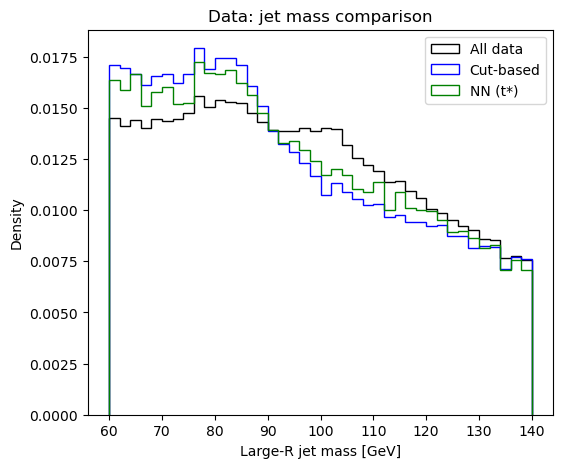

Cut-based (val MC): purity = 0.515 | eps_S = 0.550, eps_B = 0.457 (S=679, B=640)
NN (val MC):        purity = 0.618 | eps_S = 0.301, eps_B = 0.164


In [10]:
plt.figure(figsize=(6,5))

bins = 40
rng = (60, 140)

# All events
plt.hist(mass_data,
         bins=bins,
         range=rng,
         density=True,
         histtype="step",
         label="All data",
         color='black')

# Cut-based
plt.hist(mass_data[pass_cut_mask],
         bins=bins,
         range=rng,
         density=True,
         histtype="step",
         label="Cut-based",
         color='blue')

# NN
plt.hist(mass_data[nn_mask],
         bins=bins,
         range=rng,
         density=True,
         histtype="step",
         label="NN (t*)",
         color='green')

plt.xlabel("Large-R jet mass [GeV]")
plt.ylabel("Density")
plt.title("Data: jet mass comparison")
plt.legend()
plt.savefig("../outputs/Validation_purity&threshold.png", dpi=300, bbox_inches="tight")
plt.show()

S_cut = 0
B_cut = 0
S0_val = 0
B0_val = 0

for e in mc_events:
    if e.event_id not in val_eids:
        continue

    j = e.leading_jet()
    l = e.leading_lepton()
    if j is None or l is None:
        continue

    # totals before selection (for efficiencies)
    if j.truth:
        S0_val += 1
    else:
        B0_val += 1

    # cut-based selection
    if pass_cuts(e, min_pt_j, min_pt_l, min_dphi, eta_j_max):
        if j.truth:
            S_cut += 1
        else:
            B_cut += 1

purity_cut = S_cut / (S_cut + B_cut) if (S_cut + B_cut) > 0 else float("nan")
epsS_cut   = S_cut / S0_val if S0_val > 0 else float("nan")
epsB_cut   = B_cut / B0_val if B0_val > 0 else float("nan")

print(f"Cut-based (val MC): purity = {purity_cut:.3f} | eps_S = {epsS_cut:.3f}, eps_B = {epsB_cut:.3f} (S={S_cut}, B={B_cut})")
print(f"NN (val MC):        purity = {purity_star:.3f} | eps_S = {epsS_star:.3f}, eps_B = {epsB_star:.3f}")

The mass comparison graph shows that the neural network performs better than the given cut-based method. This conclusion is supported quantitatively by the validation MC results: the cut-based selection achieves a purity of 0.515, while the neural network achieves a higher purity of 0.621 at the chosen working point. Although the neural network has a lower signal efficiency (εS = 0.306 compared to 0.550 for cuts), it significantly reduces background (εB = 0.164 compared to 0.457), leading to a cleaner selected sample.

The neural network curve has a more consistent shape (ideally it should resemble a Gaussian-like distribution with a clear peak in the 80–90 GeV range corresponding to the W/Z boson mass) than the cut-based method. The peak in the correct mass range indicates that the model successfully retained signal events.

The peak in the neural network appears to have a lower density than the cut-based method. This is expected, since the NN selection is more restrictive and reduces both signal and background. However, it suppresses background much more strongly, which explains the improved purity.

The neural network was not given the particle mass as an input feature, yet it still enhances the W/Z mass region. This demonstrates that it learned correlations among the kinematic variables rather than directly using mass information.

In conclusion, while the cut-based method retains a larger fraction of signal events, it also keeps a substantial amount of background, resulting in lower purity. The neural network, by learning correlations between input features, achieves significantly better background rejection and higher purity. Therefore, it provides a more powerful and adaptable approach for signal identification across different datasets.